In [1]:
import os

from Text.self import sentence_embeddings, padding_count, zero_padding, probability_penalties

PROXY_URL = "http://127.0.0.1:23897"

os.environ["HTTP_PROXY"] = PROXY_URL
os.environ["HTTPS_PROXY"] = PROXY_URL
os.environ["http_proxy"] = PROXY_URL
os.environ["https_proxy"] = PROXY_URL

os.environ["HF_ENDPOINT"] = "https://huggingface.co"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("代理地址：", PROXY_URL)
print("Hugging Face 地址：", os.environ["HF_ENDPOINT"])

代理地址： http://127.0.0.1:23897
Hugging Face 地址： https://huggingface.co


In [2]:
import random
import sys
import time
from pathlib import Path

import huggingface_hub
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers

from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, Trainer, TrainingArguments
print("Python：", sys.version.split()[0])
print("NumPy：", np.__version__)
print("Pandas：", pd.__version__)
print("PyTorch：", torch.__version__)
print("Transformers：", transformers.__version__)
print("Hugging Face Hub：", huggingface_hub.__version__)
print("CUDA 可用：", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU 数量：", torch.cuda.device_count())
    print("当前 GPU：", torch.cuda.get_device_name(0))

Python： 3.12.3
NumPy： 2.5.1
Pandas： 2.2.3
PyTorch： 2.9.0
Transformers： 5.5.3
Hugging Face Hub： 1.14.0
CUDA 可用： True
GPU 数量： 2
当前 GPU： PPU-ZW810E


In [3]:
DATA_DIR=Path("/workspace/E-DAIC/original_data")

SPLIT_DIR=Path("/workspace/E-DAIC/splits")

LABEL_DIR = Path(
    "/workspace/E-DAIC/others"
)

TRAIN_SPLIT_FILE = (
    SPLIT_DIR / "train_split.csv"
)

DEV_SPLIT_FILE = (
    SPLIT_DIR / "dev_split.csv"
)

DETAIL_LABEL_FILE = (
    LABEL_DIR / "Detailed_PHQ8_Labels.csv"
)

CHECKPOINT_DIR = Path(
    "/workspace/E-DAIC/checkpoints/phq8_text"
)
QUESTION_COLUMNS = [
    "PHQ_8NoInterest",
    "PHQ_8Depressed",
    "PHQ_8Sleep",
    "PHQ_8Tired",
    "PHQ_8Appetite",
    "PHQ_8Failure",
    "PHQ_8Concentrating",
    "PHQ_8Moving",
]
MODEL_NAME = (
    "sentence-transformers/"
    "all-distilroberta-v1"
)

MAX_TURNS = 120
EMBEDDING_DIM = 768
NUM_CLASSES = 4

SEED = 42
BETA = 0.5
ALPHA = 1.5

BATCH_SIZE = 10
NUM_EPOCHS = 20
LEARNING_RATE = 5e-4
OPTIMIZER_EPS = 1e-8
WEIGHT_DECAY = 1e-3

EPS = 1e-12
QUESTION_NUMBER=1
device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)
required_paths = [
    DATA_DIR,
    TRAIN_SPLIT_FILE,
    DEV_SPLIT_FILE,
    DETAIL_LABEL_FILE,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    missing_text = "\n".join(
        str(path)
        for path in missing_paths
    )

    raise FileNotFoundError(
        "缺少以下数据路径：\n"
        + missing_text
    )

if not 1 <= QUESTION_NUMBER <= 8:
    raise ValueError(
        "QUESTION_NUMBER 必须是1～8"
    )

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

question_column = QUESTION_COLUMNS[
    QUESTION_NUMBER - 1
]

print("计算设备：", device)
print("数据目录：", DATA_DIR)
print("划分目录：", SPLIT_DIR)
print("标签目录：", LABEL_DIR)
print("当前题目：", question_column)
print("Checkpoint目录：", CHECKPOINT_DIR)
print("路径检查：全部通过")

计算设备： cuda:0
数据目录： /workspace/E-DAIC/original_data
划分目录： /workspace/E-DAIC/splits
标签目录： /workspace/E-DAIC/others
当前题目： PHQ_8NoInterest
Checkpoint目录： /workspace/E-DAIC/checkpoints/phq8_text
路径检查：全部通过


In [4]:
def set_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)

    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print("随机种子：", SEED)
print(
    "cuDNN确定性模式：",
    torch.backends.cudnn.deterministic,
)
print(
    "cuDNN自动测速：",
    torch.backends.cudnn.benchmark,
)

随机种子： 42
cuDNN确定性模式： True
cuDNN自动测速： False


In [11]:
train_split_df=pd.read_csv(TRAIN_SPLIT_FILE)

dev_split_df=pd.read_csv(DEV_SPLIT_FILE)

detailed_labels_df=pd.read_csv(DETAIL_LABEL_FILE)

train_split_df["Participant_ID"]=(
    train_split_df["Participant_ID"].astype(int)
)

dev_split_df["Participant_ID"]=dev_split_df["Participant_ID"].astype(int)

detailed_labels_df["Participant_ID"]=detailed_labels_df["Participant_ID"].astype(int)\

print("训练划分形状：", train_split_df.shape)
print("验证划分形状：", dev_split_df.shape)
print("详细标签形状：", detailed_labels_df.shape)

train_id_set=set(train_split_df["Participant_ID"].tolist())
dev_id_set=set(dev_split_df["Participant_ID"])

overlap_ids=train_id_set&dev_id_set
if overlap_ids:
    raise ValueError(
        "训练集与验证集存在重复参与者："
        + str(sorted(overlap_ids))
    )

print("训练/验证参与者没有重叠")

selected_columns=["Participant_ID",question_column]
train_labels_df=train_split_df[["Participant_ID"]].merge(
    detailed_labels_df[selected_columns],
           on="Participant_ID",
           how="left",
           validate="one_to_one"
          )
dev_labels_df=dev_split_df[["Participant_ID"]].merge(
    detailed_labels_df[selected_columns],
           on="Participant_ID",
           how="left",
           validate="one_to_one"
          )

if train_labels_df[
    question_column
    ].isna().any():
    raise ValueError(
        "训练集中存在缺失标签"
    )
if dev_labels_df[
    question_column
    ].isna().any():
    raise ValueError(
        "训练集中存在缺失标签"
    )

scores={0,1,2,3}
observed_train_scores= set(train_labels_df[question_column].astype(int).tolist())
observed_dev_scores=set(dev_labels_df[question_column].astype(int).tolist())
print(observed_train_scores)
if not observed_train_scores.issubset(
    scores
):
    raise ValueError(
        "训练标签中存在0～3之外的值"
    )

if not observed_dev_scores.issubset(
    scores
):
    raise ValueError(
        "验证标签中存在0～3之外的值"
    )

train_class_counts=(train_labels_df[question_column]
                    .astype(int)
                    .value_counts()
                    .reindex(range(NUM_CLASSES),fill_value=0)
                    .sort_index())
dev_class_counts = (
    dev_labels_df[
        question_column
    ]
    .astype(int)
    .value_counts()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)

print("当前题目：", question_column)
print("训练参与者数：", len(train_labels_df))
print("验证参与者数：", len(dev_labels_df))

print(
    "训练类别数量：",
    train_class_counts.to_dict(),
)

print(
    "验证类别数量：",
    dev_class_counts.to_dict(),
)

训练划分形状： (163, 6)
验证划分形状： (55, 6)
详细标签形状： (219, 10)
训练/验证参与者没有重叠
{0, 1, 2, 3}
当前题目： PHQ_8NoInterest
训练参与者数： 163
验证参与者数： 55
训练类别数量： {0: 81, 1: 57, 2: 20, 3: 5}
验证类别数量： {0: 25, 1: 22, 2: 4, 3: 4}


In [15]:
print("begin load tokenizer")

tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
print("begin load roberta")

embedder=AutoModel.from_pretrained(MODEL_NAME)
embedder=embedder.to(device)
embedder.eval()

for parameter in embedder.parameters():
    parameter.requires_grad_(False)
print("pretrain model load finished")

actual_hidden_size=embedder.config.hidden_size

if actual_hidden_size != EMBEDDING_DIM:
    raise ValueError(
        f"模型隐藏维度为 {actual_hidden_size}，"
        f"但配置中写的是 {EMBEDDING_DIM}"
    )
model_commit = getattr(
    embedder.config,
    "_commit_hash",
    None,
)

tokenizer_commit = (
    tokenizer
    .init_kwargs
    .get("_commit_hash")
)

embedder_device = next(
    embedder.parameters()
).device

trainable_embedder_parameters = sum(
    parameter.numel()
    for parameter in embedder.parameters()
    if parameter.requires_grad
)

print("Tokenizer类型：", type(tokenizer))
print("RoBERTa类型：", type(embedder))
print("隐藏维度：", actual_hidden_size)
print("模型所在设备：", embedder_device)
print("模型commit：", model_commit)
print("Tokenizer commit：", tokenizer_commit)
print(
    "RoBERTa可训练参数数量：",
    trainable_embedder_parameters,
)

begin load tokenizer
begin load roberta


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: sentence-transformers/all-distilroberta-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


pretrain model load finished
Tokenizer类型： <class 'transformers.models.roberta.tokenization_roberta.RobertaTokenizer'>
RoBERTa类型： <class 'transformers.models.roberta.modeling_roberta.RobertaModel'>
隐藏维度： 768
模型所在设备： cuda:0
模型commit： 842eaed40bee4d61673a81c92d5689a8fed7a09f
Tokenizer commit： None
RoBERTa可训练参数数量： 0


In [49]:
def mean_pooling(model_output,attention_mask):
    token_embeddings=model_output.last_hidden_state

    expanded_mask=attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

    embedding_sum=torch.sum(token_embeddings*expanded_mask,dim=1)

    valid_token_count=torch.clamp(expanded_mask.sum(dim=1),min=1e-9)

    sentence_embeddings=embedding_sum/valid_token_count
    return sentence_embeddings

def preprocess_texts(text_list):
    selected_texts=list(text_list[:MAX_TURNS])
    turn_count=len(selected_texts)
    if turn_count == 0:
        raise ValueError(
            "当前参与者没有有效文本"
        )

    encoded_input=tokenizer(
        selected_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        model_output=embedder(**encoded_input)

    sentence_embeddings=mean_pooling(model_output,encoded_input["attention_mask"])

    padding_count=MAX_TURNS-turn_count

    if padding_count>0:
        zero_padding=torch.zeros(padding_count,EMBEDDING_DIM,dtype=sentence_embeddings.dtype,device=device)

        sentence_embeddings=torch.cat(
            (sentence_embeddings,zero_padding), dim=0
        )

    sentence_embeddings=F.normalize(sentence_embeddings,p=2,dim=1)

    key_padding_mask=torch.tensor([False]*turn_count+[True]*padding_count,dtype=torch.bool)

    return sentence_embeddings.detach().cpu(),key_padding_mask


embedder(
    input_ids=encoded_input[
        "input_ids"
    ],
    attention_mask=encoded_input[
        "attention_mask"
    ],
)

In [99]:
class EDAICTextDataset(Dataset):
    def __init__(self,
                 metadata_df,
                 data_dir,
                 label_column,
                 split_name):
        super().__init__()
        self.data_dir=data_dir
        self.label_column=label_column
        self.split_name=split_name
        self.metadata_df=metadata_df

        self.samples=[]
        self.embedding_cache={}

        self.cache_hits=0
        self.cache_misses=0

        selected_metadata=metadata_df[
            [
                "Participant_ID",label_column
            ]
        ]

        for participant_id,score in (selected_metadata.itertuples(index=False,name=None)):
            participant_id=int(participant_id)
            score=int(score)

            transcript_file=data_dir/f"{participant_id}_P"/f"{participant_id}_Transcript.csv"

            if not transcript_file.is_file():
                raise FileNotFoundError(
                    "找不到转录文件："
                    + str(transcript_file)
                )
            if score < 0 or score >= NUM_CLASSES:
                raise ValueError(
                    f"参与者{participant_id}"
                    f"的标签为{score}，"
                    "应为0～3"
                )

            self.samples.append((participant_id,transcript_file,score))

            if len(self.samples)==0:
                raise ValueError(
                    f"{split_name}数据集为空"
            )
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        participant_id,transcript_file,score=self.samples[index]

        if index in self.embedding_cache:
            self.cache_hits+=1

            embeddings, mask=self.embedding_cache[index]

        else:
            self.cache_misses+=1

            transcript_df=pd.read_csv(transcript_file)
            if "Text" not in transcript_df.columns:
                raise ValueError(
                    f"{transcript_file}"
                    "中不存在Text列"
                )
            text_list=transcript_df["Text"].dropna().astype(str).tolist()

            if len(text_list) == 0:
                raise ValueError(
                    f"参与者{participant_id}"
                    "没有有效文本"
                )
            embeddings, mask=preprocess_texts(text_list)
            self.embedding_cache[index] = (embeddings, mask)

            if self.cache_misses==1 or self.cache_misses%20==0 or self.cache_misses == len(self.samples):
                print(
                    f"[{self.split_name}] "
                    "已缓存句向量："
                    f"{self.cache_misses}/"
                    f"{len(self.samples)}"
                )
        label=torch.tensor(score,dtype=torch.long)

        return embeddings,mask,label

    def cache_info(self):
        return {
            "split": self.split_name,
            "cached": len(
                self.embedding_cache
            ),
            "total": len(self.samples),
            "hits": self.cache_hits,
            "misses": self.cache_misses,
        }



In [100]:
train_dataset=EDAICTextDataset(metadata_df=train_labels_df,data_dir=DATA_DIR,label_column=question_column,split_name="train")

val_dataset=EDAICTextDataset(metadata_df=dev_labels_df,data_dir=DATA_DIR,label_column=question_column,split_name="val")

print("训练样本数：", len(train_dataset))
print("验证样本数：", len(val_dataset))

print(
    "训练缓存状态：",
    train_dataset.cache_info(),
)

print(
    "验证缓存状态：",
    val_dataset.cache_info(),
)

训练样本数： 163
验证样本数： 55
训练缓存状态： {'split': 'train', 'cached': 0, 'total': 163, 'hits': 0, 'misses': 0}
验证缓存状态： {'split': 'val', 'cached': 0, 'total': 55, 'hits': 0, 'misses': 0}


In [101]:
sample_embeddings, sample_mask, sample_label = (
    train_dataset[0]
)
sample_participant_id = (
    train_dataset.samples[0][0]
)

print("参与者：", sample_participant_id)
print("句向量：", sample_embeddings.shape)
print("Mask：", sample_mask.shape)
print("标签：", sample_label.item())
print("句向量设备：", sample_embeddings.device)

print(
    "检查后的缓存状态：",
    train_dataset.cache_info(),
)

[train] 已缓存句向量：1/163
参与者： 302
句向量： torch.Size([120, 768])
Mask： torch.Size([120])
标签： 1
句向量设备： cpu
检查后的缓存状态： {'split': 'train', 'cached': 1, 'total': 163, 'hits': 0, 'misses': 1}


In [102]:
import inspect

print(
    inspect.signature(
        EDAICTextDataset.__init__
    )
)

print(
    "train_dataset类型：",
    type(train_dataset),
)

(self, metadata_df, data_dir, label_column, split_name)
train_dataset类型： <class '__main__.EDAICTextDataset'>


In [103]:

train_generator=torch.Generator()
train_generator.manual_seed(SEED)

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=0,drop_last=False,generator=train_generator)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,num_workers=0,drop_last=False,shuffle=False)

print("训练样本数：", len(train_dataset))
print("验证样本数：", len(val_dataset))

print("训练批次数：", len(train_loader))
print("验证批次数：", len(val_loader))

print(
    "训练缓存：",
    train_dataset.cache_info(),
)

print(
    "验证缓存：",
    val_dataset.cache_info(),
)

训练样本数： 163
验证样本数： 55
训练批次数： 17
验证批次数： 6
训练缓存： {'split': 'train', 'cached': 1, 'total': 163, 'hits': 0, 'misses': 1}
验证缓存： {'split': 'val', 'cached': 0, 'total': 55, 'hits': 0, 'misses': 0}


In [104]:
class LSTMAttentionClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm=nn.LSTM(
            input_size=EMBEDDING_DIM, hidden_size=50,batch_first=True,bidirectional=True
        )
        self.attention=nn.MultiheadAttention(
            embed_dim=100,num_heads=4,dropout=0.5,batch_first=True
        )
        self.mlp=nn.Sequential(
            nn.Flatten(),nn.Dropout(0.5),nn.Linear(MAX_TURNS*100,256),nn.ReLU(),nn.Dropout(0.2),nn.Linear(256,NUM_CLASSES)
        )
    def forward(self,embeddings,key_padding_mask):
        if embeddings.ndim != 3:
            raise ValueError(
                "embeddings必须是三维张量，"
                f"实际形状：{embeddings.shape}"
            )
        expected_embedding_shape=(MAX_TURNS,EMBEDDING_DIM)

        if embeddings.shape[1:] != expected_embedding_shape:
            raise ValueError(
                "句向量形状错误："
                f"{embeddings.shape}，"
                "预期后两维为"
                f"{expected_embedding_shape}"
            )
        if key_padding_mask.shape != (
            embeddings.shape[0],
            MAX_TURNS,
        ):
            raise ValueError(
                "mask形状错误："
                f"{key_padding_mask.shape}"
            )

        lstm_output, _=self.lstm(embeddings)
        attention_output,_=self.attention(query=lstm_output,key=lstm_output,value=lstm_output,key_padding_mask=key_padding_mask,need_weights=False)

        logits=self.mlp(attention_output)

        return logits


In [105]:
set_seed(SEED)

model = LSTMAttentionClassifier()
model = model.to(device)

def count_trainable_parameters(module):
    return sum(parameter.numel() for parameter in module.parameters() if parameter.requires_grad)
lstm_parameter_count = (
    count_trainable_parameters(
        model.lstm
    )
)

attention_parameter_count = (
    count_trainable_parameters(
        model.attention
    )
)

mlp_parameter_count = (
    count_trainable_parameters(
        model.mlp
    )
)

total_parameter_count = (
    count_trainable_parameters(
        model
    )
)

print("模型设备：",
      next(model.parameters()).device)

print("LSTM参数：",
      f"{lstm_parameter_count:,}")

print("Attention参数：",
      f"{attention_parameter_count:,}")

print("MLP参数：",
      f"{mlp_parameter_count:,}")

print("总可训练参数：",
      f"{total_parameter_count:,}")

模型设备： cuda:0
LSTM参数： 328,000
Attention参数： 40,400
MLP参数： 3,073,284
总可训练参数： 3,441,684


In [106]:
class_count_tensor=torch.tensor(train_class_counts.to_numpy(),dtype=torch.float32)
if (class_count_tensor==0).any():
    raise ValueError(
        "训练集存在没有样本的类别，"
        "无法计算倒数频率权重"
    )
training_sample_count = (
    class_count_tensor.sum()
)

inverse_frequency=training_sample_count/class_count_tensor

class_weights=inverse_frequency.pow(BETA)

class_weights=class_weights.to(device)
print("训练类别数量：",
      class_count_tensor)

print("训练样本总数：",
      training_sample_count.item())

print("Beta：", BETA)
print("类别权重：",
      class_weights)
print("权重设备：",
      class_weights.device)

训练类别数量： tensor([81., 57., 20.,  5.])
训练样本总数： 163.0
Beta： 0.5
类别权重： tensor([1.4186, 1.6910, 2.8548, 5.7096], device='cuda:0')
权重设备： cuda:0


In [107]:
def imbalanced_ordinal_loss(logits,labels,class_weights,alpha):
    if logits.ndim != 2:
        raise ValueError(
            "logits必须是二维张量"
        )

    if logits.shape[1] != NUM_CLASSES:
        raise ValueError(
            "logits的类别维度必须为4"
        )

    if labels.ndim != 1:
        raise ValueError(
            "labels必须是一维张量"
        )

    if logits.shape[0] != labels.shape[0]:
        raise ValueError(
            "logits和labels的batch大小不一致"
        )

    labels=labels.long()

    probabilities=F.softmax(logits,dim=1)

    class_ids=torch.arange(NUM_CLASSES,device=logits.device).unsqueeze(0)

    oridinal_distances=torch.abs(labels.unsqueeze(1) - class_ids).float()

    sample_class_weights=class_weights[labels].unsqueeze(1)

    weighted_distances=sample_class_weights*oridinal_distances

    probability_penalties=-torch.log(1.0-probabilities+EPS)

    per_class_losses=probability_penalties*weighted_distances.pow(alpha)

    per_sample_losses=per_class_losses.sum(dim=1)

    loss=per_sample_losses.mean()

    return loss


In [108]:
def compute_metrics(predictions,labels):
    predictions=predictions.detach().cpu().long()

    labels=labels.detach().cpu().long()

    if predictions.shape != labels.shape:
        raise ValueError(
            "预测与标签形状不一致："
            f"{predictions.shape} vs "
            f"{labels.shape}"
        )

    if predictions.numel() == 0:
        raise ValueError(
            "没有可用于评价的样本"
        )

    confusion_matrix=torch.zeros(NUM_CLASSES,NUM_CLASSES,dtype=torch.long)

    for true_label,prediction in zip(labels,predictions):
        confusion_matrix[true_label.item(),prediction.item()]+=1

    true_positive=torch.diag(confusion_matrix).float()

    predicted_count=confusion_matrix.sum(dim=0).float()

    support=confusion_matrix.sum(dim=1).float()

    false_positive=predicted_count-true_positive

    false_negative=support-true_positive

    precision=true_positive/(predicted_count+EPS)

    recall=true_positive/(support+EPS)

    f1_per_class=2*precision*recall/(precision+recall+EPS)

    macro_f1=f1_per_class.mean()

    weighted_f1=(f1_per_class*support).sum()/(support.sum()+EPS)

    total_true_positive = (
        true_positive.sum()
    )

    total_false_positive = (
        false_positive.sum()
    )

    total_false_negative = (
        false_negative.sum()
    )

    micro_precision = (
        total_true_positive
        / (
            total_true_positive
            + total_false_positive
            + EPS
        )
    )

    micro_recall = (
        total_true_positive
        / (
            total_true_positive
            + total_false_negative
            + EPS
        )
    )

    micro_f1 = (
        2
        * micro_precision
        * micro_recall
        / (
            micro_precision
            + micro_recall
            + EPS
        )
    )

    accuracy = (
        predictions == labels
    ).float().mean()

    predictions_float = (
        predictions.float()
    )

    labels_float = labels.float()

    prediction_mean = (
        predictions_float.mean()
    )

    label_mean = (
        labels_float.mean()
    )

    prediction_variance = (
        predictions_float.var(
            correction=1
        )
    )

    label_variance = (
        labels_float.var(
            correction=1
        )
    )

    covariance = (
        (
            predictions_float
            - prediction_mean
        )
        * (
            labels_float
            - label_mean
        )
    ).sum() / (
        predictions_float.numel()
        - 1
    )

    ccc = (
        2 * covariance
    ) / (
        prediction_variance
        + label_variance
        + (
            prediction_mean
            - label_mean
        ).pow(2)
        + EPS
    )

    rmse = torch.sqrt(
        F.mse_loss(
            predictions_float,
            labels_float,
        )
    )

    mae = F.l1_loss(
        predictions_float,
        labels_float,
    )

    return {
        "accuracy": accuracy.item(),
        "micro_f1": micro_f1.item(),
        "macro_f1": macro_f1.item(),
        "weighted_f1": (
            weighted_f1.item()
        ),
        "ccc": ccc.item(),
        "rmse": rmse.item(),
        "mae": mae.item(),
        "f1_per_class": (
            f1_per_class
        ),
        "confusion_matrix": (
            confusion_matrix
        ),
    }
def print_metrics(
    title,
    metrics,
):
    print(title)

    print(
        f"  Loss:        "
        f"{metrics['loss']:.6f}"
    )

    print(
        f"  Accuracy:    "
        f"{metrics['accuracy']:.4f}"
    )

    print(
        f"  Micro F1:    "
        f"{metrics['micro_f1']:.4f}"
    )

    print(
        f"  Macro F1:    "
        f"{metrics['macro_f1']:.4f}"
    )

    print(
        f"  Weighted F1: "
        f"{metrics['weighted_f1']:.4f}"
    )

    print(
        f"  CCC:         "
        f"{metrics['ccc']:.4f}"
    )

    print(
        f"  RMSE:        "
        f"{metrics['rmse']:.4f}"
    )

    print(
        f"  MAE:         "
        f"{metrics['mae']:.4f}"
    )

    print(
        "  每类F1：     ",
        metrics["f1_per_class"],
    )

    print(
        "  混淆矩阵：\n",
        metrics["confusion_matrix"],
    )

In [109]:
def evaluate(model,dataloader,dataset,class_weights,alpha,device):
    model.eval()

    total_loss=0.0
    all_predictions=[]
    all_labels=[]

    evalutaion_start=time.time()

    with torch.no_grad():
        for batch_index,batch in enumerate(dataloader,start=1):
            embeddings,key_padding_mask,labels=batch
            embeddings=embeddings.to(device)

            key_padding_mask=key_padding_mask.to(device)

            labels=labels.to(device)

            logits=model(embeddings,key_padding_mask)

            loss=imbalanced_ordinal_loss(logits=logits,labels=labels,class_weights=class_weights,alpha=alpha)

            batch_size=labels.size(0)

            total_loss+=loss.item()*batch_size

            predictions=torch.argmax(logits,dim=1)

            all_predictions.append(predictions.cpu())

            all_labels.append(labels.cpu())

            print(
                f"  验证Batch "
                f"{batch_index}/"
                f"{len(dataloader)} "
                f"完成"
            )

        predictions=torch.cat(all_predictions,dim=0)

        labels=torch.cat(all_labels,dim=0)

        metrics=compute_metrics(predictions,labels)

        metrics["loss"]=total_loss/len(dataset)

        metrics["elapsed_seconds"]=time.time()-evalutaion_start

        return metrics

In [110]:
print("开始计算未训练模型的验证基线")
print(
    "第一次验证需要计算55人的RoBERTa向量，"
    "可能耗时较长"
)

baseline_metrics = evaluate(
    model=model,
    dataloader=val_loader,
    dataset=val_dataset,
    class_weights=class_weights,
    alpha=ALPHA,
    device=device,
)

print_metrics(
    "未训练模型验证结果",
    baseline_metrics,
)

print(
    "验证耗时：",
    f"{baseline_metrics['elapsed_seconds']:.2f}秒",
)

print(
    "验证缓存状态：",
    val_dataset.cache_info(),
)

开始计算未训练模型的验证基线
第一次验证需要计算55人的RoBERTa向量，可能耗时较长
[val] 已缓存句向量：1/55
  验证Batch 1/6 完成
[val] 已缓存句向量：20/55
  验证Batch 2/6 完成
  验证Batch 3/6 完成
[val] 已缓存句向量：40/55
  验证Batch 4/6 完成
  验证Batch 5/6 完成
[val] 已缓存句向量：55/55
  验证Batch 6/6 完成
未训练模型验证结果
  Loss:        6.246691
  Accuracy:    0.4000
  Micro F1:    0.4000
  Macro F1:    0.1429
  Weighted F1: 0.2286
  CCC:         0.0000
  RMSE:        0.9045
  MAE:         0.6727
  每类F1：      tensor([0.0000, 0.5714, 0.0000, 0.0000])
  混淆矩阵：
 tensor([[ 0, 25,  0,  0],
        [ 0, 22,  0,  0],
        [ 0,  4,  0,  0],
        [ 0,  4,  0,  0]])
验证耗时： 2.23秒
验证缓存状态： {'split': 'val', 'cached': 55, 'total': 55, 'hits': 0, 'misses': 55}


In [111]:
MAX_GRAD_NORM=1.0

optimizer=torch.optim.Adam(model.parameters(),lr=5e-4,eps=OPTIMIZER_EPS,weight_decay=WEIGHT_DECAY)

def train_one_epoch(model,dataloader,dataset,optimizer,class_weights,alpha,device,max_grad_norm):
    model.train()
    total_loss=0.0
    total_gradient_norm=0.0

    all_predictions=[]
    all_labels=[]

    start_time=time.time()

    for batch_index, batch in enumerate(dataloader,start=1):
        embeddings,key_padding_mask,labels=batch

        embeddings=embeddings.to(device)
        key_padding_mask=key_padding_mask.to(device)
        labels=labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits=model(embeddings,key_padding_mask)

        loss=imbalanced_ordinal_loss(logits=logits,labels=labels,class_weights=class_weights,alpha=alpha)

        loss.backward()

        gradient_norm=torch.nn.utils.clip_grad_norm_(model.parameters(),max_grad_norm)

        optimizer.step()

        batch_size=labels.size(0)

        total_loss+=loss.item()*batch_size

        total_gradient_norm+=gradient_norm

        predictions=torch.argmax(logits,dim=1)

        all_predictions.append(predictions.cpu())
        all_labels.append(labels.cpu())

        print(
            f"\r训练Batch "
            f"{batch_index}/{len(dataloader)} "
            f"Loss={loss.item():.6f}",
            end="",
        )
        print()

    predictions = torch.cat(
        all_predictions,
        dim=0,
    )
    labels = torch.cat(
        all_labels,
        dim=0,
    )

    # 计算整轮训练的指标
    metrics = compute_metrics(
        predictions=predictions,
        labels=labels,
    )

    metrics["loss"] = (
        total_loss / len(dataset)
    )

    metrics["average_gradient_norm"] = (
        total_gradient_norm / len(dataloader)
    )

    metrics["elapsed_seconds"] = (
        time.time() - start_time
    )

    return metrics


In [112]:
print("开始训练第1轮")
print("第一次训练需要计算并缓存训练集RoBERTa向量")
print("因此第1轮会比较慢，之后会明显变快")


train_metrics_epoch_1 = train_one_epoch(
    model=model,
    dataloader=train_loader,
    dataset=train_dataset,
    optimizer=optimizer,
    class_weights=class_weights,
    alpha=ALPHA,
    device=device,
    max_grad_norm=MAX_GRAD_NORM,
)


print_metrics(
    "第1轮训练结果",
    train_metrics_epoch_1,
)

print(
    "平均梯度长度：",
    train_metrics_epoch_1[
        "average_gradient_norm"
    ],
)

print(
    "训练耗时：",
    round(
        train_metrics_epoch_1[
            "elapsed_seconds"
        ],
        2,
    ),
    "秒",
)


val_metrics_epoch_1 = evaluate(
    model=model,
    dataloader=val_loader,
    dataset=val_dataset,
    class_weights=class_weights,
    alpha=ALPHA,
    device=device,
)


print_metrics(
    "第1轮验证结果",
    val_metrics_epoch_1,
)


print(
    "训练缓存状态：",
    train_dataset.cache_info(),
)

print(
    "验证缓存状态：",
    val_dataset.cache_info(),
)

开始训练第1轮
第一次训练需要计算并缓存训练集RoBERTa向量
因此第1轮会比较慢，之后会明显变快
训练Batch 1/17 Loss=4.032791
[train] 已缓存句向量：20/163
训练Batch 2/17 Loss=7.510087
训练Batch 3/17 Loss=3.934515
[train] 已缓存句向量：40/163
训练Batch 4/17 Loss=2.980204
训练Batch 5/17 Loss=3.438506
[train] 已缓存句向量：60/163
训练Batch 6/17 Loss=2.288599
训练Batch 7/17 Loss=7.166286
[train] 已缓存句向量：80/163
训练Batch 8/17 Loss=8.310627
训练Batch 9/17 Loss=2.623553
[train] 已缓存句向量：100/163
训练Batch 10/17 Loss=3.038130
训练Batch 11/17 Loss=2.042843
[train] 已缓存句向量：120/163
训练Batch 12/17 Loss=3.230501
训练Batch 13/17 Loss=8.413104
[train] 已缓存句向量：140/163
训练Batch 14/17 Loss=2.662158
训练Batch 15/17 Loss=7.368391
[train] 已缓存句向量：160/163
训练Batch 16/17 Loss=3.302696
[train] 已缓存句向量：163/163
训练Batch 17/17 Loss=1.217463
第1轮训练结果
  Loss:        4.460628
  Accuracy:    0.3620
  Micro F1:    0.3620
  Macro F1:    0.1477
  Weighted F1: 0.2168
  CCC:         -0.0092
  RMSE:        0.8722
  MAE:         0.6748
  每类F1：      tensor([0.0698, 0.5209, 0.0000, 0.0000])
  混淆矩阵：
 tensor([[ 3, 78,  0,  0],
   

In [113]:
checkpoint_dir=Path(CHECKPOINT_DIR)

LR=5e-4

checkpoint_dir.mkdir(parents=True,exist_ok=True)

best_loss_path=checkpoint_dir/f"phq{QUESTION_NUMBER}_seed{SEED}_best_loss.pt"

best_ccc_path=checkpoint_dir/f"phq{QUESTION_NUMBER}_seed{SEED}_best_ccc.pt"

def metrics_to_cpu(metrics):
    copied_metircs={}

    for key,value in metrics.items():
        if isinstance(value,torch.Tensor):
            copied_metircs[key]=value.detach().cpu()
        else:
            copied_metircs[key]=value
    return copied_metircs

def save_checkpoint(checkpoint_path,checkpoint_type,epoch,model,optimizer,train_metrics,val_metrics):
    checkpoint={
        # 当前训练到第几轮
        "epoch": epoch,

        # 说明它是最佳Loss还是最佳CCC
        "checkpoint_type": checkpoint_type,

        # 分类模型的全部参数
        "model_state_dict": (
            model.state_dict()
        ),

        # Adam优化器的状态
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),

        # 当前轮训练和验证指标
        "train_metrics": metrics_to_cpu(
            train_metrics
        ),
        "val_metrics": metrics_to_cpu(
            val_metrics
        ),

        # 实验配置
        "question_number": QUESTION_NUMBER,
        "model_name": MODEL_NAME,
        "seed": SEED,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "beta": BETA,
        "alpha": ALPHA,
        "max_turns": MAX_TURNS,
        "embedding_dim": EMBEDDING_DIM,
        "num_classes": NUM_CLASSES,

        # 保存类别权重，方便复现实验
        "class_weights": (
            class_weights.detach().cpu()
        ),
    }
    torch.save(
        checkpoint,
        checkpoint_path,
    )

    print(
        f"已保存{checkpoint_type}："
        f"{checkpoint_path}"
    )

In [114]:
best_val_loss = (
    val_metrics_epoch_1["loss"]
)

best_val_ccc = (
    val_metrics_epoch_1["ccc"]
)

best_loss_epoch = 1
best_ccc_epoch = 1


history = [
    {
        "epoch": 1,
        "train": train_metrics_epoch_1,
        "val": val_metrics_epoch_1,
    }
]


save_checkpoint(
    checkpoint_path=best_loss_path,
    checkpoint_type="best_loss",
    epoch=1,
    model=model,
    optimizer=optimizer,
    train_metrics=train_metrics_epoch_1,
    val_metrics=val_metrics_epoch_1,
)


save_checkpoint(
    checkpoint_path=best_ccc_path,
    checkpoint_type="best_ccc",
    epoch=1,
    model=model,
    optimizer=optimizer,
    train_metrics=train_metrics_epoch_1,
    val_metrics=val_metrics_epoch_1,
)
print(
    "最佳Loss checkpoint存在：",
    best_loss_path.exists(),
)

print(
    "最佳CCC checkpoint存在：",
    best_ccc_path.exists(),
)

print(
    "最佳Loss文件大小：",
    round(
        best_loss_path.stat().st_size
        / 1024**2,
        2,
    ),
    "MB",
)

print(
    "最佳CCC文件大小：",
    round(
        best_ccc_path.stat().st_size
        / 1024**2,
        2,
    ),
    "MB",
)

已保存best_loss：/workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_best_loss.pt
已保存best_ccc：/workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_best_ccc.pt
最佳Loss checkpoint存在： True
最佳CCC checkpoint存在： True
最佳Loss文件大小： 39.41 MB
最佳CCC文件大小： 39.41 MB


In [115]:
last_checkpoint_path = (
    checkpoint_dir
    / f"phq{QUESTION_NUMBER}_seed{SEED}_last.pt"
)


# 先把第1轮保存成当前的last checkpoint
save_checkpoint(
    checkpoint_path=last_checkpoint_path,
    checkpoint_type="last",
    epoch=1,
    model=model,
    optimizer=optimizer,
    train_metrics=train_metrics_epoch_1,
    val_metrics=val_metrics_epoch_1,
)


print()
print(
    f"继续训练：第2轮到第{NUM_EPOCHS}轮"
)
print(
    "训练集和验证集向量已经缓存，"
    "后面的训练会快很多"
)


for epoch in range(
    2,
    NUM_EPOCHS + 1,
):
    print()
    print("=" * 60)
    print(
        f"Epoch {epoch}/{NUM_EPOCHS}"
    )
    print("=" * 60)

    # ---------- 训练 ----------
    train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        dataset=train_dataset,
        optimizer=optimizer,
        class_weights=class_weights,
        alpha=ALPHA,
        device=device,
        max_grad_norm=MAX_GRAD_NORM,
    )

    # ---------- 验证 ----------
    val_metrics = evaluate(
        model=model,
        dataloader=val_loader,
        dataset=val_dataset,
        class_weights=class_weights,
        alpha=ALPHA,
        device=device,
    )

    # 保存这一轮的指标到历史记录
    history.append(
        {
            "epoch": epoch,
            "train": train_metrics,
            "val": val_metrics,
        }
    )

    # 打印这一轮的主要结果
    print(
        f"Epoch {epoch:02d} | "
        f"训练Loss={train_metrics['loss']:.6f} | "
        f"验证Loss={val_metrics['loss']:.6f}"
    )

    print(
        f"           "
        f"验证Accuracy="
        f"{val_metrics['accuracy']:.4f} | "
        f"验证Macro F1="
        f"{val_metrics['macro_f1']:.4f} | "
        f"验证CCC="
        f"{val_metrics['ccc']:.4f}"
    )

    # ---------- 保存最新模型 ----------
    save_checkpoint(
        checkpoint_path=last_checkpoint_path,
        checkpoint_type="last",
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        train_metrics=train_metrics,
        val_metrics=val_metrics,
    )

    # ---------- 判断最佳Loss ----------
    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]
        best_loss_epoch = epoch

        print(
            "发现更低的验证Loss：",
            f"{best_val_loss:.6f}",
        )

        save_checkpoint(
            checkpoint_path=best_loss_path,
            checkpoint_type="best_loss",
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            train_metrics=train_metrics,
            val_metrics=val_metrics,
        )

    else:
        print(
            "验证Loss没有超过历史最佳，"
            f"当前最佳为第{best_loss_epoch}轮："
            f"{best_val_loss:.6f}"
        )

    # ---------- 判断最佳CCC ----------
    if val_metrics["ccc"] > best_val_ccc:

        best_val_ccc = val_metrics["ccc"]
        best_ccc_epoch = epoch

        print(
            "发现更高的验证CCC：",
            f"{best_val_ccc:.6f}",
        )

        save_checkpoint(
            checkpoint_path=best_ccc_path,
            checkpoint_type="best_ccc",
            epoch=epoch,
            model=model,
            optimizer=optimizer,
            train_metrics=train_metrics,
            val_metrics=val_metrics,
        )

    else:
        print(
            "验证CCC没有超过历史最佳，"
            f"当前最佳为第{best_ccc_epoch}轮："
            f"{best_val_ccc:.6f}"
        )

已保存last：/workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_last.pt

继续训练：第2轮到第20轮
训练集和验证集向量已经缓存，后面的训练会快很多

Epoch 2/20
训练Batch 1/17 Loss=2.038645
训练Batch 2/17 Loss=2.659044
训练Batch 3/17 Loss=2.624762
训练Batch 4/17 Loss=3.118073
训练Batch 5/17 Loss=2.657252
训练Batch 6/17 Loss=8.179628
训练Batch 7/17 Loss=8.495879
训练Batch 8/17 Loss=2.231148
训练Batch 9/17 Loss=3.135795
训练Batch 10/17 Loss=7.508800
训练Batch 11/17 Loss=2.542033
训练Batch 12/17 Loss=8.206371
训练Batch 13/17 Loss=1.760832
训练Batch 14/17 Loss=7.484607
训练Batch 15/17 Loss=2.238435
训练Batch 16/17 Loss=2.729632
训练Batch 17/17 Loss=3.292009
  验证Batch 1/6 完成
  验证Batch 2/6 完成
  验证Batch 3/6 完成
  验证Batch 4/6 完成
  验证Batch 5/6 完成
  验证Batch 6/6 完成
Epoch 02 | 训练Loss=4.208499 | 验证Loss=6.126254
           验证Accuracy=0.4000 | 验证Macro F1=0.1429 | 验证CCC=0.0000
已保存last：/workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_last.pt
验证Loss没有超过历史最佳，当前最佳为第1轮：5.625433
验证CCC没有超过历史最佳，当前最佳为第1轮：0.000000

Epoch 3/20
训练Batch 1/17 Loss=7.591859
训练Batch 2/17 Loss=2.601599
训练Ba

In [116]:
print()
print("=" * 60)
print("20轮训练全部结束")
print("=" * 60)

print(
    f"最佳验证Loss："
    f"{best_val_loss:.6f}，"
    f"出现在第{best_loss_epoch}轮"
)

print(
    f"最佳验证CCC："
    f"{best_val_ccc:.6f}，"
    f"出现在第{best_ccc_epoch}轮"
)

print(
    "历史记录轮数：",
    len(history),
)

print(
    "Best Loss checkpoint：",
    best_loss_path,
)

print(
    "Best CCC checkpoint：",
    best_ccc_path,
)

print(
    "Last checkpoint：",
    last_checkpoint_path,
)


20轮训练全部结束
最佳验证Loss：5.420553，出现在第10轮
最佳验证CCC：0.457297，出现在第13轮
历史记录轮数： 20
Best Loss checkpoint： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_best_loss.pt
Best CCC checkpoint： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_best_ccc.pt
Last checkpoint： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_last.pt


In [117]:
def load_checkpoint_model(
    checkpoint_path,
    device,
):
    # 读取checkpoint文件
    #
    # map_location="cpu"表示先读取到CPU，
    # 避免模型和优化器状态一次性占用GPU显存
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    # 创建一个结构完全相同的新模型
    restored_model = (
        LSTMAttentionClassifier()
        .to(device)
    )

    # 把checkpoint中的模型参数装进去
    load_result = (
        restored_model.load_state_dict(
            checkpoint["model_state_dict"]
        )
    )

    # 切换为验证模式
    restored_model.eval()

    print(
        "已加载Checkpoint：",
        checkpoint_path,
    )

    print(
        "保存轮数：",
        checkpoint["epoch"],
    )

    print(
        "Checkpoint类型：",
        checkpoint["checkpoint_type"],
    )

    print(
        "缺少的参数：",
        load_result.missing_keys,
    )

    print(
        "多余的参数：",
        load_result.unexpected_keys,
    )

    return restored_model, checkpoint

In [118]:
checkpoint_paths = {
    "best_loss": best_loss_path,
    "best_ccc": best_ccc_path,
    "last": last_checkpoint_path,
}


checkpoint_results = {}


for checkpoint_name, checkpoint_path in (
    checkpoint_paths.items()
):
    print()
    print("=" * 60)
    print(
        "正在验证：",
        checkpoint_name,
    )
    print("=" * 60)

    restored_model, checkpoint = (
        load_checkpoint_model(
            checkpoint_path=checkpoint_path,
            device=device,
        )
    )

    restored_metrics = evaluate(
        model=restored_model,
        dataloader=val_loader,
        dataset=val_dataset,
        class_weights=class_weights,
        alpha=ALPHA,
        device=device,
    )

    print_metrics(
        f"{checkpoint_name}重新验证结果",
        restored_metrics,
    )

    checkpoint_results[
        checkpoint_name
    ] = {
        "epoch": checkpoint["epoch"],
        "loss": restored_metrics["loss"],
        "accuracy": restored_metrics["accuracy"],
        "micro_f1": restored_metrics["micro_f1"],
        "macro_f1": restored_metrics["macro_f1"],
        "weighted_f1": restored_metrics[
            "weighted_f1"
        ],
        "ccc": restored_metrics["ccc"],
        "rmse": restored_metrics["rmse"],
        "mae": restored_metrics["mae"],
    }

    # 当前循环验证完后释放临时模型
    del restored_model
    del checkpoint


正在验证： best_loss
已加载Checkpoint： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_best_loss.pt
保存轮数： 10
Checkpoint类型： best_loss
缺少的参数： []
多余的参数： []
  验证Batch 1/6 完成
  验证Batch 2/6 完成
  验证Batch 3/6 完成
  验证Batch 4/6 完成
  验证Batch 5/6 完成
  验证Batch 6/6 完成
best_loss重新验证结果
  Loss:        5.420553
  Accuracy:    0.1636
  Micro F1:    0.1636
  Macro F1:    0.1020
  Weighted F1: 0.1195
  CCC:         0.1243
  RMSE:        1.1521
  MAE:         1.0000
  每类F1：      tensor([0.0000, 0.2745, 0.1333, 0.0000])
  混淆矩阵：
 tensor([[ 0, 18,  7,  0],
        [ 0,  7, 15,  0],
        [ 0,  2,  2,  0],
        [ 0,  2,  2,  0]])

正在验证： best_ccc
已加载Checkpoint： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_best_ccc.pt
保存轮数： 13
Checkpoint类型： best_ccc
缺少的参数： []
多余的参数： []
  验证Batch 1/6 完成
  验证Batch 2/6 完成
  验证Batch 3/6 完成
  验证Batch 4/6 完成
  验证Batch 5/6 完成
  验证Batch 6/6 完成
best_ccc重新验证结果
  Loss:        5.621704
  Accuracy:    0.5273
  Micro F1:    0.5273
  Macro F1:    0.3672
  Weighted F1: 0.5286
  CCC:    

In [119]:
checkpoint_comparison_df = (
    pd.DataFrame
    .from_dict(
        checkpoint_results,
        orient="index",
    )
)

checkpoint_comparison_df.index.name = (
    "checkpoint"
)

display(
    checkpoint_comparison_df.round(4)
)

,epoch,loss,accuracy,micro_f1,macro_f1,weighted_f1,ccc,rmse,mae
checkpoint,,,,,,,,,
best_loss,10,5.4206,0.1636,0.1636,0.1020,0.1195,0.1243,1.1521,1.0000
best_ccc,13,5.6217,0.5273,0.5273,0.3672,0.5286,0.4573,0.8202,0.5273
last,20,9.0622,0.5273,0.5273,0.3575,0.4974,0.2135,0.9630,0.6000


In [120]:
final_model,final_checkpoint=load_checkpoint_model(checkpoint_path=best_ccc_path, device=device)
print(
    "最终采用的Checkpoint：",
    final_checkpoint["checkpoint_type"],
)

print(
    "最终采用的训练轮数：",
    final_checkpoint["epoch"],
)

print(
    "模型当前设备：",
    next(final_model.parameters()).device,
)

已加载Checkpoint： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_best_ccc.pt
保存轮数： 13
Checkpoint类型： best_ccc
缺少的参数： []
多余的参数： []
最终采用的Checkpoint： best_ccc
最终采用的训练轮数： 13
模型当前设备： cuda:0


In [121]:
def predict_dataloader(model,dataloader,device):
    model.eval()

    all_probabilities=[]
    all_predicitions=[]
    all_labels=[]

    with torch.no_grad():
        for batch in dataloader:
            embeddings,key_padding_mask,labels=batch

            embeddings=embeddings.to(device)

            key_padding_mask=key_padding_mask.to(device)

            labels=labels.to(device).long()

            logits=model(embeddings, key_padding_mask)

            probabilities=torch.softmax(logits, dim=-1)

            predictions=torch.argmax(probabilities, dim=-1)

            all_probabilities.append(probabilities.cpu())

            all_predicitions.append(predictions.cpu())

            all_labels.append(labels.cpu())

        probabilities=torch.cat(all_probabilities,dim=0)

        predictions=torch.cat(all_predicitions,dim=0)

        labels=torch.cat(all_labels,dim=0)

        return probabilities,predictions,labels


In [122]:
final_probabilities,final_predictions,final_labels=predict_dataloader(model=final_model, dataloader=val_loader, device=device)
print(
    "概率形状：",
    final_probabilities.shape,
)

print(
    "预测标签形状：",
    final_predictions.shape,
)

print(
    "真实标签形状：",
    final_labels.shape,
)

print(
    "第一个人的四类概率：",
    final_probabilities[0],
)

print(
    "第一个人的概率之和：",
    final_probabilities[0].sum().item(),
)

print(
    "各预测类别人数：",
    torch.bincount(
        final_predictions,
        minlength=NUM_CLASSES,
    ),
)

概率形状： torch.Size([55, 4])
预测标签形状： torch.Size([55])
真实标签形状： torch.Size([55])
第一个人的四类概率： tensor([5.5691e-01, 4.3531e-01, 7.6315e-03, 1.4800e-04])
第一个人的概率之和： 0.9999999403953552
各预测类别人数： tensor([16, 29, 10,  0])


In [123]:
participant_ids=val_dataset.metadata_df["Participant_ID"].astype(int).to_numpy()

assert (
    len(participant_ids)
    == len(final_predictions)
), "参与者数量与预测数量不一致"

prediction_df = pd.DataFrame(
    {
        "Participant_ID": participant_ids,
        "True_Label": (
            final_labels.numpy()
        ),
        "Predicted_Label": (
            final_predictions.numpy()
        ),
        "Correct": (
            final_predictions
            == final_labels
        ).numpy(),
        "Absolute_Error": (
            final_predictions
            - final_labels
        ).abs().numpy(),
        "Confidence": (
            final_probabilities
            .max(dim=1)
            .values
            .numpy()
        ),
        "Probability_0": (
            final_probabilities[:, 0]
            .numpy()
        ),
        "Probability_1": (
            final_probabilities[:, 1]
            .numpy()
        ),
        "Probability_2": (
            final_probabilities[:, 2]
            .numpy()
        ),
        "Probability_3": (
            final_probabilities[:, 3]
            .numpy()
        ),
    }
)
prediction_csv_path = (
    checkpoint_dir
    / (
        f"phq{QUESTION_NUMBER}_"
        f"seed{SEED}_"
        f"val_predictions.csv"
    )
)


prediction_df.to_csv(
    prediction_csv_path,
    index=False,
)


display(
    prediction_df.head(10)
)

print(
    "预测结果已保存到：",
    prediction_csv_path,
)

print(
    "预测结果形状：",
    prediction_df.shape,
)

print(
    "预测正确人数：",
    prediction_df["Correct"].sum(),
)

print(
    "预测错误人数：",
    (
        ~prediction_df["Correct"]
    ).sum(),
)

,Participant_ID,True_Label,Predicted_Label,Correct,Absolute_Error,Confidence,Probability_0,Probability_1,Probability_2,Probability_3
0,300,0,0,True,0,0.556912,0.556912,0.435308,0.007632,0.000148
1,301,0,0,True,0,0.510547,0.510547,0.472349,0.016749,0.000356
2,306,0,1,False,1,0.553453,0.402180,0.553453,0.043694,0.000673
3,317,1,1,True,0,0.620333,0.264751,0.620333,0.114157,0.000758
4,320,1,2,False,1,0.581427,0.052947,0.364814,0.581427,0.000812
5,321,2,2,True,0,0.862907,0.006431,0.130594,0.862907,0.000068
6,331,1,2,False,1,0.858655,0.006958,0.134308,0.858655,0.000079
7,334,1,1,True,0,0.614615,0.274418,0.614615,0.110133,0.000834
8,336,0,1,False,1,0.605206,0.193188,0.605206,0.200618,0.000988
9,343,1,1,True,0,0.504999,0.102551,0.504999,0.391407,0.001042


预测结果已保存到： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_val_predictions.csv
预测结果形状： (55, 10)
预测正确人数： 29
预测错误人数： 26


In [124]:
history_rows = []


for epoch_record in history:
    epoch = epoch_record["epoch"]
    train_metrics = epoch_record["train"]
    val_metrics = epoch_record["val"]

    history_rows.append(
        {
            "epoch": epoch,

            "train_loss": (
                train_metrics["loss"]
            ),
            "val_loss": (
                val_metrics["loss"]
            ),

            "train_accuracy": (
                train_metrics["accuracy"]
            ),
            "val_accuracy": (
                val_metrics["accuracy"]
            ),

            "train_macro_f1": (
                train_metrics["macro_f1"]
            ),
            "val_macro_f1": (
                val_metrics["macro_f1"]
            ),

            "train_ccc": (
                train_metrics["ccc"]
            ),
            "val_ccc": (
                val_metrics["ccc"]
            ),
        }
    )


history_df = pd.DataFrame(
    history_rows
)


history_csv_path = (
    checkpoint_dir
    / (
        f"phq{QUESTION_NUMBER}_"
        f"seed{SEED}_"
        f"training_history.csv"
    )
)


history_df.to_csv(
    history_csv_path,
    index=False,
)


display(
    history_df.round(4)
)


print(
    "训练历史形状：",
    history_df.shape,
)

print(
    "训练历史已保存：",
    history_csv_path,
)

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_ccc,val_ccc
0,1,4.4606,5.6254,0.3620,0.4000,0.1477,0.1429,-0.0092,0.0000
1,2,4.2085,6.1263,0.3497,0.4000,0.1295,0.1429,0.0000,0.0000
2,3,4.3883,6.1987,0.3497,0.4000,0.1295,0.1429,0.0000,0.0000
3,4,4.2980,6.2508,0.3497,0.4000,0.1295,0.1429,0.0000,0.0000
4,5,4.3824,6.1407,0.3497,0.4000,0.1295,0.1429,0.0000,0.0000
5,6,4.3538,6.2217,0.3436,0.4000,0.1279,0.1429,-0.0052,0.0000
6,7,4.3087,5.9930,0.3497,0.4000,0.1301,0.1429,-0.0217,0.0000
7,8,4.0919,6.2640,0.3681,0.4000,0.2193,0.1429,0.0749,0.0000
8,9,4.0307,5.9207,0.3497,0.4000,0.1295,0.1429,0.0000,0.0000
9,10,3.8939,5.4206,0.3681,0.1636,0.2334,0.1020,0.1658,0.1243


训练历史形状： (20, 9)
训练历史已保存： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_training_history.csv


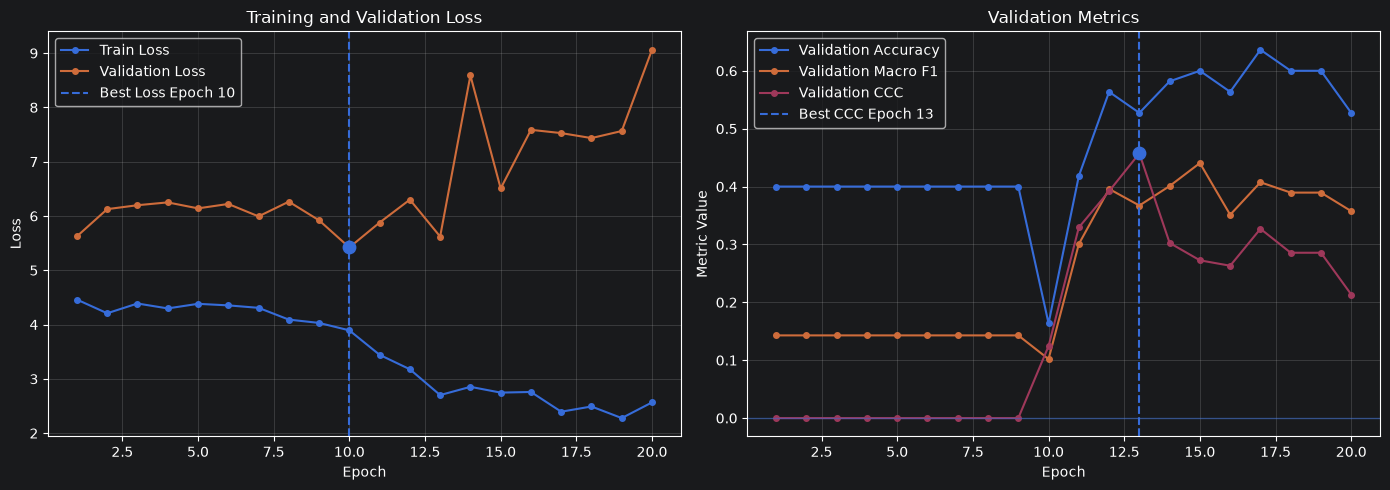

训练曲线已保存： /workspace/E-DAIC/checkpoints/phq8_text/phq1_seed42_training_curves.png


In [125]:
import matplotlib.pyplot as plt


figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
)


loss_axis = axes[0]
metric_axis = axes[1]


# 第一张图：训练Loss和验证Loss
loss_axis.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    markersize=4,
    label="Train Loss",
)

loss_axis.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    markersize=4,
    label="Validation Loss",
)


# 标记最佳验证Loss所在轮数
loss_axis.axvline(
    x=best_loss_epoch,
    linestyle="--",
    label=(
        f"Best Loss Epoch "
        f"{best_loss_epoch}"
    ),
)

loss_axis.scatter(
    best_loss_epoch,
    best_val_loss,
    s=80,
    zorder=5,
)


loss_axis.set_title(
    "Training and Validation Loss"
)

loss_axis.set_xlabel("Epoch")
loss_axis.set_ylabel("Loss")
loss_axis.grid(alpha=0.3)
loss_axis.legend()


# 第二张图：三个验证指标
metric_axis.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    markersize=4,
    label="Validation Accuracy",
)

metric_axis.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    marker="o",
    markersize=4,
    label="Validation Macro F1",
)

metric_axis.plot(
    history_df["epoch"],
    history_df["val_ccc"],
    marker="o",
    markersize=4,
    label="Validation CCC",
)


# 标记最佳CCC所在轮数
metric_axis.axvline(
    x=best_ccc_epoch,
    linestyle="--",
    label=(
        f"Best CCC Epoch "
        f"{best_ccc_epoch}"
    ),
)

metric_axis.scatter(
    best_ccc_epoch,
    best_val_ccc,
    s=80,
    zorder=5,
)


metric_axis.axhline(
    y=0,
    linewidth=1,
    alpha=0.5,
)

metric_axis.set_title(
    "Validation Metrics"
)

metric_axis.set_xlabel("Epoch")
metric_axis.set_ylabel("Metric Value")
metric_axis.grid(alpha=0.3)
metric_axis.legend()


figure.tight_layout()


curve_path = (
    checkpoint_dir
    / (
        f"phq{QUESTION_NUMBER}_"
        f"seed{SEED}_"
        f"training_curves.png"
    )
)


figure.savefig(
    curve_path,
    dpi=200,
    bbox_inches="tight",
)


plt.show()


print(
    "训练曲线已保存：",
    curve_path,
)

In [126]:
resume_checkpoint = torch.load(
    last_checkpoint_path,
    map_location="cpu",
    weights_only=False,
)


# 重新创建完全相同的模型结构
resume_model = (
    LSTMAttentionClassifier()
    .to(device)
)


# 先创建一个新的Adam优化器
resume_optimizer = torch.optim.Adam(
    resume_model.parameters(),
    lr=LR,
    eps=OPTIMIZER_EPS,
    weight_decay=WEIGHT_DECAY,
)


# 恢复第20轮模型参数
model_load_result = (
    resume_model.load_state_dict(
        resume_checkpoint[
            "model_state_dict"
        ]
    )
)


# 恢复Adam内部状态
resume_optimizer.load_state_dict(
    resume_checkpoint[
        "optimizer_state_dict"
    ]
)


resume_epoch = int(
    resume_checkpoint["epoch"]
)

next_epoch = resume_epoch + 1


print(
    "恢复的Checkpoint类型：",
    resume_checkpoint[
        "checkpoint_type"
    ],
)

print(
    "已经完成的轮数：",
    resume_epoch,
)

print(
    "继续训练时的下一轮：",
    next_epoch,
)

print(
    "缺少的模型参数：",
    model_load_result.missing_keys,
)

print(
    "多余的模型参数：",
    model_load_result.unexpected_keys,
)

print(
    "恢复后的学习率：",
    resume_optimizer.param_groups[0]["lr"],
)

print(
    "恢复后的weight_decay：",
    resume_optimizer.param_groups[0][
        "weight_decay"
    ],
)

恢复的Checkpoint类型： last
已经完成的轮数： 20
继续训练时的下一轮： 21
缺少的模型参数： []
多余的模型参数： []
恢复后的学习率： 0.0005
恢复后的weight_decay： 0.001


In [127]:
optimizer_state_devices = set()


for parameter_state in (
    resume_optimizer.state.values()
):
    for state_value in (
        parameter_state.values()
    ):
        if torch.is_tensor(state_value):
            optimizer_state_devices.add(
                state_value.device
            )


print(
    "恢复后的模型设备：",
    next(
        resume_model.parameters()
    ).device,
)

print(
    "Adam内部张量设备：",
    optimizer_state_devices,
)

print(
    "Adam已经记录的参数数量：",
    len(resume_optimizer.state),
)

恢复后的模型设备： cuda:0
Adam内部张量设备： {device(type='cuda', index=0), device(type='cpu')}
Adam已经记录的参数数量： 16


In [128]:
resume_metrics = evaluate(
    model=resume_model,
    dataloader=val_loader,
    dataset=val_dataset,
    class_weights=class_weights,
    alpha=ALPHA,
    device=device,
)


print_metrics(
    "恢复后的Last Checkpoint结果",
    resume_metrics,
)


saved_last_ccc = (
    resume_checkpoint[
        "val_metrics"
    ]["ccc"]
)


print(
    "Checkpoint中记录的CCC：",
    saved_last_ccc,
)

print(
    "重新计算得到的CCC：",
    resume_metrics["ccc"],
)

print(
    "两次CCC的差值：",
    abs(
        resume_metrics["ccc"]
        - saved_last_ccc
    ),
)

  验证Batch 1/6 完成
  验证Batch 2/6 完成
  验证Batch 3/6 完成
  验证Batch 4/6 完成
  验证Batch 5/6 完成
  验证Batch 6/6 完成
恢复后的Last Checkpoint结果
  Loss:        9.062162
  Accuracy:    0.5273
  Micro F1:    0.5273
  Macro F1:    0.3575
  Weighted F1: 0.4974
  CCC:         0.2135
  RMSE:        0.9630
  MAE:         0.6000
  每类F1：      tensor([0.6316, 0.4651, 0.3333, 0.0000])
  混淆矩阵：
 tensor([[18,  7,  0,  0],
        [11, 10,  1,  0],
        [ 1,  2,  1,  0],
        [ 2,  2,  0,  0]])
Checkpoint中记录的CCC： 0.21349836885929108
重新计算得到的CCC： 0.21349836885929108
两次CCC的差值： 0.0
